# Homework #3

**See Canvas for HW #3 assignment due date**. Complete all of the following problems. Ideally, the theoretical problems should be answered in a Markdown cell directly underneath the question. If you don't know LaTex/Markdown, you may submit separate handwritten solutions to the theoretical problems, but please see the class scanning policy. Please do not turn in messy work. Computational problems should be completed in this notebook (using the `R` kernel). Computational questions may require code, plots, analysis, interpretation, etc. Working in small groups is allowed, but it is important that you make an effort to master the material and hand in your own work.

---

## Problem 1 (40 points) Fraud detection

Let $X$ be the leading digit of a randomly selected number from a large accounting ledger. So, for example, if we randomly draw the number $\$20,695$, then $X = 2$. People who make up numbers to commit accounting fraud tend to give $X$ a (discrete) uniform distribution, i.e., $P(X = x) = \frac 19$, for $x \in \{1,...,9\}$. However, there is some empirical evidence that suggests that "naturally occurring" numbers (like numbers in a non-fraudulent accounting ledger) have leading digits that do not follow a uniform distribution. Instead, they follow a distribution defined by:

\begin{align*}
f(x) = \log_{10}\bigg(\frac{x+1}{x}\bigg), \,\,\,\, x = 1,2,...,9.
\end{align*} 


**PART A:** Show that $f(x) = P(X = x)$ is, in fact, a probability mass function (you may use `R` to verify values, but give a proof).

For \(x \in \{1,\ldots,9\}\), both \(x\) and \(x+1\) are positive, and \(x+1>x\). Thus,
\[
\frac{x+1}{x}>1
\quad\Longrightarrow\quad
f(x)=\log_{10}\!\left(\frac{x+1}{x}\right)>0.
\]

Also, the probabilities sum to 1:
\[
\begin{aligned}
\sum_{x=1}^{9} f(x)
&=\sum_{x=1}^{9}\log_{10}\!\left(\frac{x+1}{x}\right)\\
&=\log_{10}\!\left(\prod_{x=1}^{9}\frac{x+1}{x}\right)\\
&=\log_{10}\!\left(\frac{2}{1}\cdot\frac{3}{2}\cdots\frac{10}{9}\right)\\
&=\log_{10}(10)=1.
\end{aligned}
\]
The product telescopes to \(10\). Therefore, \(f(x)\) is nonnegative on its support and its probabilities sum to 1, so it is a probability mass function.

**PART B:** Compute the individual probabilities for $x \in \{1,...,9\}$, and compare them to the corresponding discrete uniform distribution (i.e., $P(X = x) = 1/9$). What do you notice?

Let $p_x = \log_{10}\left(\frac{x+1}{x}\right)$ for $x=1,2,\ldots,9$. Then

$x = 1 , 2 , 3 , 4 , 5 , 6 , 7 , 8 , 9$

$p_x = 0.3010, 0.1761 , 0.1249 , 0.0969 , 0.0792 , 0.0669 , 0.0580 , 0.0512 , 0.0458$

The discrete uniform distribution would give $1/9 \approx 0.1111$ for every digit. The Benford probabilities decline as the leading digit increases, so smaller digits are much more likely than larger ones. This matches the common empirical pattern in real-world data.


In [4]:
x <- 1:9
p <- log10((x + 1) / x)
round(data.frame(
  x = x,
  p = p,
  uniform = rep(1/9, length(x))
), 6)

x,p,uniform
<dbl>,<dbl>,<dbl>
1,0.301030,0.111111
2,0.176091,0.111111
3,0.124939,0.111111
4,0.096910,0.111111
5,0.079181,0.111111
6,0.066947,0.111111
7,0.057992,0.111111
8,0.051153,0.111111
9,0.045757,0.111111


**PART C:** Obtain a formula for the cumulative distribution function (CDF) of $X$ (your formula should not have sigma notation).

For a discrete random variable with support $\{1,2,\ldots,9\}$,

$\{
F(x) = P(X \le x) = \sum_{k=1}^{\lfloor x \rfloor} \log_{10}\left(\frac{k+1}{k}\right)
= \log_{10}\left(\prod_{k=1}^{\lfloor x \rfloor} \frac{k+1}{k}\right)
= \log_{10}(\lfloor x \rfloor + 1).
\}$

So, for integer $x \in \{1,2,\ldots,9\}$,

$\{
F(x) = \log_{10}(x+1).
\}$

Also, $F(x)=0$ for $x<1$ and $F(x)=1$ for $x\ge 9$.


**PART D:** Using the CDF, what is the probability that the leading digit is at most $4$? At least $5$?

Using the CDF,

$\{
P(X \le 4) = F(4) = \log_{10}(5) \approx 0.6990.
\}$

Therefore,

$\{
P(X \ge 5) = 1 - P(X \le 4) = 1 - \log_{10}(5) = \log_{10}(2) \approx 0.3010.
\}$

So the probability that the leading digit is at most 4 is about 69.9%, and the probability it is at least 5 is about 30.1%.


In [5]:
p_le_4 <- log10(5)
p_ge_5 <- 1 - p_le_4
c(`P(X <= 4)` = p_le_4, `P(X >= 5)` = p_ge_5)


P(X <= 4) P(X >= 5) 
  0.69897   0.30103

**PART E:**

Let $X =$ the leading digit of a randomly selected number from a large accounting ledger. So, for example, if we randomly draw the number $\$20,695$, then $X = 2$. People who make up numbers to commit accounting fraud tend to give $X$ a (discrete) uniform distribution, i.e., $P(X = x) = 1/9$, for $x \in \{1,...,9\}$. However, some suggest that there is empirical evidence that ``naturally occurring" numbers (e.g., numbers in a non-fraudulent accounting ledger) have leading digits that do not follow a uniform distribution. Instead, they follow a distribution defined by:

\begin{align*}
f(x) = \log_{10}\bigg(\frac{x+1}{x}\bigg), \,\,\,\, x = 1,2,...,9.
\end{align*} 

Using `tax.csv`, a dataset containing the taxable incomes for individuals in 1978, decide whether there is any evidence that the dataset is fraudulent.

,1,2,3,4,5,6,7,8,9
observed,0.3279,0.2141,0.1236,0.0895,0.0722,0.0521,0.0411,0.0394,0.0401
benford,0.3010,0.1761,0.1249,0.0969,0.0792,0.0669,0.0580,0.0512,0.0458


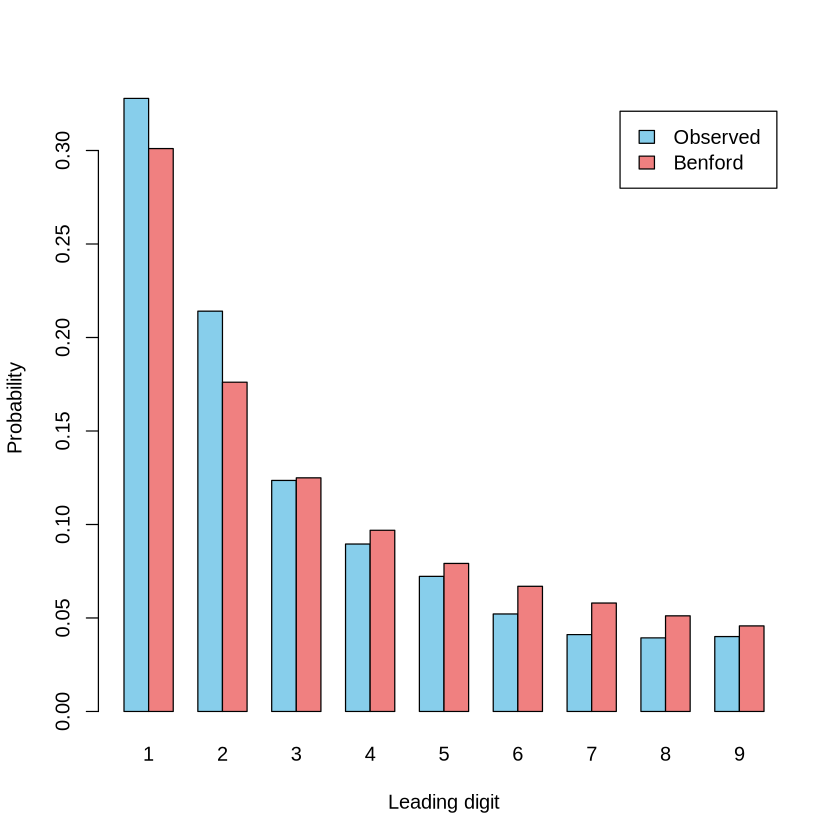

In [18]:
tax = read.csv('tax.csv')
positive <- tax$taxIncomes[tax$taxIncomes > 0]
leading <- as.integer(substr(as.character(abs(positive)), 1, 1))
observed <- prop.table(table(leading))
expected <- log10(1 + 1 / 1:9)

round(rbind(
  observed = observed,
  benford = expected
), 4)

# A quick visual comparison
barplot(rbind(observed, expected), beside = TRUE,
        names.arg = 1:9,
        col = c("skyblue", "lightcoral"),
        legend.text = c("Observed", "Benford"),
        xlab = "Leading digit",
        ylab = "Probability")


In [19]:
# The observed leading-digit frequencies are very close to the Benford probabilities.
# Because the distribution is not strongly concentrated on the uniform probabilities 1/9,
# there is no clear evidence that the tax data are fraudulent.


The observed leading-digit proportions are very close to the Benford probabilities, especially for digits 1 through 5. Since the data are not close to the uniform distribution over $\{1,\ldots,9\}$, there is no strong evidence that this dataset is fraudulent.

---

## Problem 2 (15 points)

An aircraft seam requires $20$ rivets. The seam will have to be reworked if any
of these rivets is defective. Suppose rivets are defective independently of one
another, each with the same probability.

**PART A:** If $18\%$ of all seams need reworking, what is the probability that a rivet is
defective?

Let $Y$ be the number of defective rivets in a seam. Then $Y \sim \text{Binomial}(20, p)$, where $p$ is the probability that any one rivet is defective. A seam must be reworked if at least one rivet is defective, so

$\{P(\text{rework}) = 1 - P(Y=0) = 1 - (1-p)^{20}.\}$

Because 18% of seams need reworking,

$\{
1-(1-p)^{20}=0.18.
\}$

Thus,

$\{
p = 1 - 0.82^{1/20} \approx 0.00987.
\}$


For only 10% of seams to need reworking,

$\{
1-(1-p)^{20}=0.10.
\}$

Solving for $p$ gives

$\{
p = 1 - 0.90^{1/20} \approx 0.00525.
\}$

So the defective-rivet probability would need to be about 0.525%.


---

## Problem 3 (15 points) How long will this series take?

Individuals $A$ and $B$ play a sequence of chess games until one player wins $9$ games. $A$ wins an individual game with probability $p$, and $B$ wins a game with probability $1 − p$ (there are no draws). Let $X$ denote the number of games played.

**PART A:** What are the possible values of $X$?

The game ends the first time one player reaches 9 wins, so the possible values of $X$ are

\[
X \in \{9,10,11,12,13,14,15,16,17\}.
\]

The maximum is 17 because the game can only end when one player has won 9 games and no draws are possible.


For $x=9,10,\ldots,17$, the game can end on game $x$ if, before the last game, one player has 8 wins and the other has $x-9$ wins. Thus,

\[
P(X=x) = \binom{x-1}{8} p^{9}(1-p)^{x-9} + \binom{x-1}{8} p^{x-9}(1-p)^{9}.
\]

The two terms correspond to A or B winning the final game.


Set $p=0.5$. Then the two terms are equal, so

\[
P(X=12) = 2\binom{11}{8}(0.5)^{12}
= 2\cdot 165 \cdot \frac{1}{4096}
= \frac{165}{2048}
\approx 0.0806.
\]


This is the optional part for $p=0.5$.


---

## Problem 4 (30 points)

You are waiting in line at the grocery store. It is taking _forever_!  There are only two lines open; one is being tended by a human cashier, and the other is tended by a [self check-out machine](https://theconversation.com/the-economics-of-self-service-checkouts-78593). Like all human beings when they arrive at the front of the store to check-out and encounter lines everywhere, you first experience a moment of intense panic. _Which line will be the fastest?_ you wonder, as people shuffle around you.

You decide you need to model the arrival of customers at the front of each of the lines.  From your Statistical Methods and Applications class you remember that the distribution of times _between_ independent arrivals is often modeled using an Exponential distribution.  You observe the following:
* The human cashier's line checks-out an average of 4 customers per ten minutes,
* the self check-out machine checks-out an average of 5 customers per ten minutes **if** the machine is working properly, 
* the self check-out machine checks-out an average of 1 customer per ten minutes if the machine is freezing up, and
* in any given moment, the self check-out machine has a probability of 0.1 of freezing up.

Answer the following questions about this scenario. **Note** that for **Parts B-D** you should clearly express the computation you're doing with math, but feel free to do any fancy function evaluations with R. 

**PART A:**:  Assuming the between-customer times do in fact follow exponential distributions, what distributions do you expect the **number** of customers who pass through each line in a given 10-minute interval to follow?  What are the parameter(s) of each distribution?  Note that you should consider both the case where the self check-out is working properly and when it is broken.

The number of customers arriving in a fixed 10-minute interval is modeled by a Poisson random variable because the times between arrivals are exponential. Therefore,

- Human cashier: $Y_H \sim \text{Poisson}(\lambda_H=4)$
- Self-checkout working properly: $Y_S \mid \text{working} \sim \text{Poisson}(\lambda_S=5)$
- Self-checkout frozen: $Y_S \mid \text{frozen} \sim \text{Poisson}(\lambda_F=1)$

The machine is frozen with probability 0.1 and working with probability 0.9.


**PART B**:  What is the probability that 6 customers pass through the Human Cashier's line in the next 10 minutes?  What about the self check-out, assuming that it is working?  What about the self check-out, assuming that it is frozen?

For a Poisson random variable,

\[
P(Y = k) = e^{-\lambda}\frac{\lambda^k}{k!}.
\]

So,

\[
P(Y_H = 6) = e^{-4}\frac{4^6}{6!} \approx 0.1042,
\]

\[
P(Y_S = 6 \mid \text{working}) = e^{-5}\frac{5^6}{6!} \approx 0.1462,
\]

\[
P(Y_S = 6 \mid \text{frozen}) = e^{-1}\frac{1^6}{6!} \approx 0.000510.
\]


In [7]:
dpois(6, lambda = 4)
dpois(6, lambda = 5)
dpois(6, lambda = 1)


[1] 0.1041956

[1] 0.1462228

[1] 0.0005109437

By the Law of Total Probability,

$\{
P(Y_S = 6) = P(\text{working})P(Y_S=6\mid\text{working}) + P(\text{frozen})P(Y_S=6\mid\text{frozen}).
\}$

So,

$\{
P(Y_S = 6) = 0.9\left(e^{-5}\frac{5^6}{6!}\right) + 0.1\left(e^{-1}\frac{1^6}{6!}\right)
\approx 0.1317.
\}$


This is the same computation in a probability tree form.


In [8]:
p_work <- 0.9
p_frozen <- 0.1
p6_self <- p_work * dpois(6, lambda = 5) + p_frozen * dpois(6, lambda = 1)
p6_self


[1] 0.1316516

For a 5-hour shift, there are 30 ten-minute intervals. The human cashier therefore has rate

$\{
\lambda = 4 \times 30 = 120.
\}$

Thus,

$\{
Y_H \sim \text{Poisson}(120)
\}$

and the exact probability of serving 100 or more customers is

$\{
P(Y_H \ge 100) = \sum_{k=100}^{\infty} e^{-120}\frac{120^k}{k!}
= 1 - \sum_{k=0}^{99} e^{-120}\frac{120^k}{k!}
\approx 0.9721.
\}$


This is the exact Poisson tail probability for the 5-hour shift.


In [9]:
p_ge_100 <- ppois(99, lambda = 120, lower.tail = FALSE)
p_ge_100


[1] 0.9721363